# Phase 7 — Compare Better Models (Random Forest, Gradient Boosting, XGBoost)

**What:** train three modern tree-based models and compare them against the Phase 5 logistic
regression baseline on identical data.

**Why:** logistic regression draws one straight boundary in feature space (linear). Tree
ensembles fit complex, non-linear boundaries and capture feature interactions automatically —
e.g. *"hot AND humid AND monsoon month"* — which matters for rainfall. The comparison is
honest: same chronological split, same preprocessing, and each model is judged at its **own
best decision threshold** (the Phase 6 lesson), so no model is handicapped by the default 0.5.

## 1. Setup

We run from `notebooks/`, so we add the project root and `src/` to the import path and
reuse the exact same splits and helpers as every other phase.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd()
if (cwd / "src").exists():
    BASE = cwd
elif (cwd.parent / "src").exists():
    BASE = cwd.parent
else:
    BASE = cwd
sys.path.insert(0, str(BASE / "src"))
sys.path.insert(0, str(BASE))

from split_data import load_splits
from evaluate import evaluate_model, find_best_threshold
from train import (
    build_baseline_pipeline,
    build_random_forest_pipeline,
    build_gradient_boosting_pipeline,
    build_xgboost_pipeline,
)

X_train, X_test, y_train, y_test = load_splits(BASE / "data" / "processed" / "splits")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("rain rate  train:", round(float(y_train.mean()), 4), "| test:", round(float(y_test.mean()), 4))

X_train: (12156, 16) | X_test: (3040, 16)
rain rate  train: 0.1044 | test: 0.248


## 2. The four contestants

| Model | Idea | Notes for our problem |
|-------|------|----------------------|
| LogisticRegression | linear boundary | Phase 5 baseline |
| RandomForest | many deep trees averaged (bagging) | `class_weight="balanced"` fights the 10% rain rate |
| GradientBoosting | trees added one by one, each fixing the last errors | usually strongest classical model; slower to fit |
| XGBoost | regularized gradient boosting | `scale_pos_weight` (≈9) counters class imbalance |

All four share the same preprocessing (scale numerics, one-hot `Season`), so differences come
from the model family only.

In [2]:
scale_pos_weight = round((len(y_train) - y_train.sum()) / y_train.sum())
models = {
    "LogisticRegression": build_baseline_pipeline(),
    "RandomForest": build_random_forest_pipeline(),
    "GradientBoosting": build_gradient_boosting_pipeline(),
    "XGBoost": build_xgboost_pipeline(scale_pos_weight=scale_pos_weight),
}
print("scale_pos_weight for XGBoost =", scale_pos_weight)
for name, pipe in models.items():
    print(f"{name:20s}", pipe.steps[-1][1].__class__.__name__)

scale_pos_weight for XGBoost = 9
LogisticRegression   LogisticRegression
RandomForest         RandomForestClassifier
GradientBoosting     GradientBoostingClassifier
XGBoost              XGBClassifier


## 3. Train all four

Each fit is timed. GradientBoosting is expected to be the slowest; XGBoost the fastest of
the tree models thanks to its compiled core.

In [3]:
import time

results = {}
for name, pipe in models.items():
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0
    results[name] = {"pipeline": pipe, "fit_s": round(fit_s, 1)}
    print(f"fitted {name:20s} in {fit_s:6.1f}s")

fitted LogisticRegression   in    0.6s


fitted RandomForest         in    2.5s


fitted GradientBoosting     in   16.2s


fitted XGBoost              in    2.4s


## 4. Ranking by ROC-AUC (threshold-free)

ROC-AUC ignores the decision threshold: it measures how well the model **ranks** rainy days
above non-rainy ones. It is the fairest first comparison.

In [4]:
from sklearn.metrics import roc_auc_score

for name, r in results.items():
    y_prob = r["pipeline"].predict_proba(X_test)[:, 1]
    r["roc_auc"] = roc_auc_score(y_test, y_prob)
    print(f"{name:20s} ROC-AUC: {r['roc_auc']:.3f}")

LogisticRegression   ROC-AUC: 0.917
RandomForest         ROC-AUC: 0.924


GradientBoosting     ROC-AUC: 0.920


XGBoost              ROC-AUC: 0.922


## 5. Metrics at the default 0.5 threshold

Raw scores with the default cutoff — this is where tree models usually underperform on the
minority (rain) class: unweighted trees lean toward the majority.

In [5]:
rows = []
for name, r in results.items():
    m = evaluate_model(r["pipeline"], X_test, y_test)  # threshold = 0.5
    rows.append({"model": name, **{k: round(v, 3) for k, v in m.items()}})
default_df = pd.DataFrame(rows).set_index("model")
default_df

,threshold,accuracy,precision,recall,f1
model,,,,,
LogisticRegression,0.5,0.848,0.828,0.491,0.616
RandomForest,0.5,0.860,0.685,0.805,0.740
GradientBoosting,0.5,0.860,0.817,0.562,0.666
XGBoost,0.5,0.856,0.667,0.841,0.744


## 6. Give every model its best threshold (out-of-fold, training only)

Same honest protocol as Phase 6: `cross_val_predict` (5-fold) on the **training** set picks
the F1-max threshold for each model. The test set stays untouched until the final evaluation.

In [6]:
for name, r in results.items():
    r["threshold"] = find_best_threshold(r["pipeline"], X_train, y_train)
    print(f"{name:20s} best F1 threshold: {r['threshold']:.2f}")

LogisticRegression   best F1 threshold: 0.25


RandomForest         best F1 threshold: 0.60


GradientBoosting     best F1 threshold: 0.25


XGBoost              best F1 threshold: 0.70


## 7. Final comparison at each model's best threshold

The real competition. Each model is evaluated **once**, on the test set, at its own tuned
threshold. ROC-AUC and fit time are shown alongside.

In [7]:
rows = []
for name, r in results.items():
    m = evaluate_model(r["pipeline"], X_test, y_test, threshold=r["threshold"])
    m["ROC-AUC"] = r["roc_auc"]
    m["fit_s"] = r["fit_s"]
    rows.append({"model": name, **{k: round(v, 3) for k, v in m.items()}})
final_df = pd.DataFrame(rows).set_index("model").sort_values("f1", ascending=False)
final_df

,threshold,accuracy,precision,recall,f1,ROC-AUC,fit_s
model,,,,,,,
GradientBoosting,0.25,0.871,0.734,0.752,0.743,0.920,16.2
RandomForest,0.60,0.866,0.719,0.756,0.737,0.924,2.5
LogisticRegression,0.25,0.870,0.749,0.719,0.733,0.917,0.6
XGBoost,0.70,0.867,0.736,0.725,0.731,0.922,2.4


## 8. Pick the winner

The project cares about *catching rain* (recall) without crying wolf constantly, so F1 is the
deciding metric. The bar chart shows recall vs F1 for every model at its own threshold.

Winner: GradientBoosting | F1 = 0.743 @ threshold 0.25


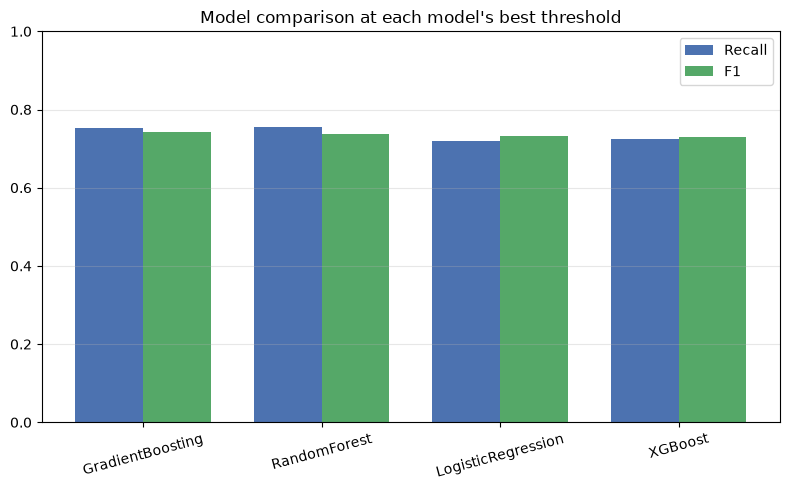

Saved -> G:\Machine Learning Models\1st Model\reports\figures\07_model_comparison.png


In [8]:
import matplotlib.pyplot as plt

best_name = final_df.index[0]
best = final_df.loc[best_name]
print(f"Winner: {best_name} | F1 = {best['f1']:.3f} @ threshold {best['threshold']:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(final_df))
width = 0.38
ax.bar(x - width / 2, final_df["recall"], width, label="Recall", color="#4C72B0")
ax.bar(x + width / 2, final_df["f1"], width, label="F1", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(final_df.index, rotation=15)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_title("Model comparison at each model's best threshold")
plt.tight_layout()

out = BASE / "reports" / "figures" / "07_model_comparison.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=120, bbox_inches="tight")
plt.show()
print("Saved ->", out)

## 9. Save the winning model

Persist the full pipeline plus its tuned threshold as one artifact. The threshold travels
with the model so every consumer (API, app) uses the same decision rule.

In [9]:
import joblib

MODEL_PATH = BASE / "models" / "karachi_rain_model.pkl"
joblib.dump(
    {
        "model_name": best_name,
        "threshold": float(best["threshold"]),
        "pipeline": results[best_name]["pipeline"],
    },
    MODEL_PATH,
)
print("Saved ->", MODEL_PATH)

Saved -> G:\Machine Learning Models\1st Model\models\karachi_rain_model.pkl
